In [ ]:
unsupervised learning:
it is one of ml technique which is used for working with unlabelled data
it consists of mainly two types:
1.clustering
2.Association rule learning

In [ ]:
1.clustering:
it is used to divide data into similar group of elements

KMeans
hiearchical clustering
dbscan(density based spatial clustering of application with noise)
gmm(gaussian mixture model)
pca(principle component analysis)

In [ ]:
KMeans:
it is one of the simplest and most popular algorithms available in the clustering

choose the number of clusters(k)
randomly intialize k centroids
assign each point to the nearest centroid point
update the centroid point just taking mean all the assignment points
repeat this process until there is no change in the centroid

In [ ]:
hiearchical clustering:
it looks like tree-structure which is also called as dendrogram

two types:

Agglomerative clustering(bottom-up)

Divisive clustering(top-bottom)

linkage methods:
single linkage:it is used to calculate minimum distance between points in clusters
complete linkage:maximum linkage
average linkage:average distances between the data points
ward linkage:it is used to minimize the variance between the clusters

In [ ]:
dbscan:
density based spatial clustering applications with noise
these clusters form based on the density of the data
it helps to detect the noise(outliers)

it consists of parameters:
eps
min samples

In [ ]:
gmm(gaussian mixture models):

it is one of the probabilistic approach

pca(principle component analysis):
it helps to reduce the dimensions

In [ ]:
evaluation metrics of clustering:
silhouette
davies bouldin
calinski harabasz

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("Mall_customers.csv")

In [6]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
x=data[['Annual Income (k$)','Spending Score (1-100)']]

In [4]:
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [9]:
from sklearn.cluster import KMeans

In [10]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

C:\Users\Kavyashree N\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Kavyashree N\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Kavyashree N\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Kavyashree N\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to 

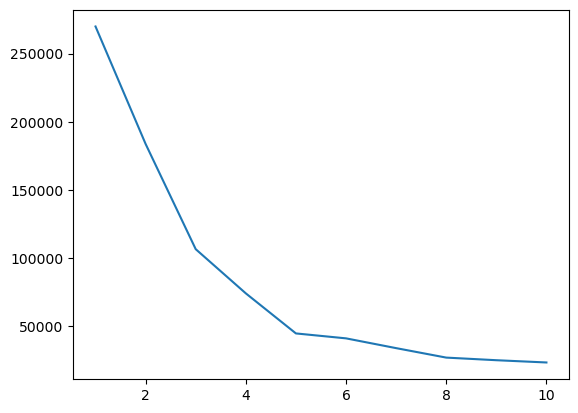

In [11]:
plt.plot(range(1,11),wcss)

In [12]:
kmeans=KMeans(n_clusters=5,random_state=42)
y_kmeans=kmeans.fit_predict(x_scaled)
data['KMeans_Cluster']=y_kmeans

C:\Users\Kavyashree N\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [13]:
y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

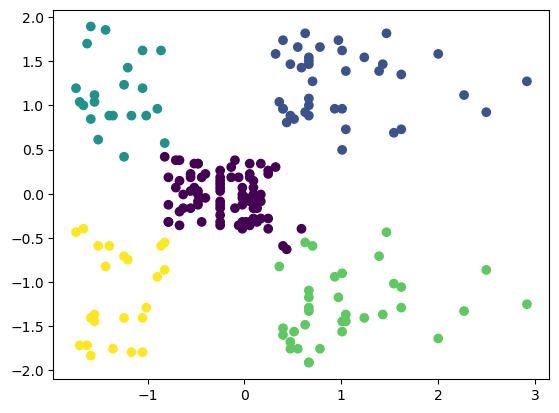

In [14]:
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=y_kmeans)

In [15]:
from sklearn.cluster import AgglomerativeClustering

In [16]:
hc=AgglomerativeClustering(n_clusters=5)
y_hc=hc.fit_predict(x_scaled)

In [17]:
y_hc

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int64)

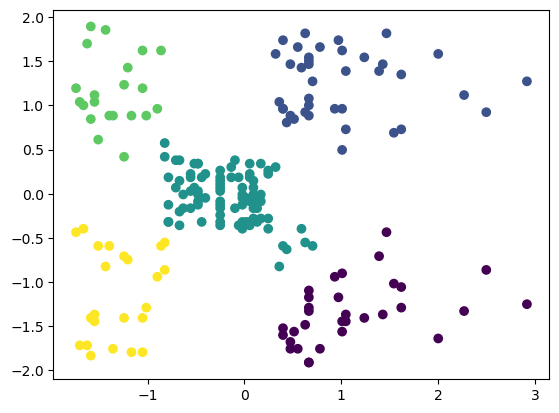

In [18]:
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=y_hc)

In [19]:
from sklearn.cluster import DBSCAN

In [20]:
dbscan=DBSCAN(eps=0.5,min_samples=5)
y_dbscan=dbscan.fit_predict(x_scaled)

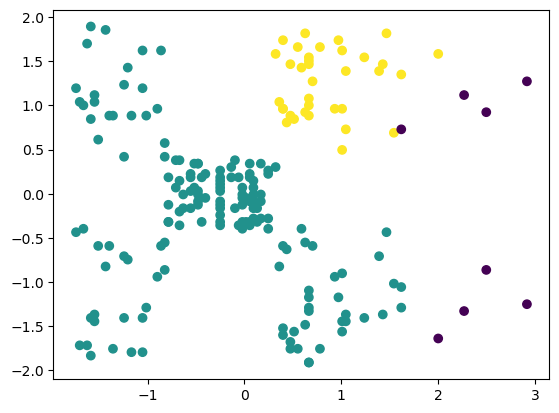

In [21]:
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=y_dbscan)

In [22]:
from sklearn.decomposition import PCA

In [23]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

In [24]:
from sklearn.mixture import GaussianMixture

In [25]:
gm=GaussianMixture(n_components=5,random_state=42)
gm.fit(x_pca)
y_gmm=gm.predict(x_pca)

C:\Users\Kavyashree N\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [26]:
y_gmm

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int64)

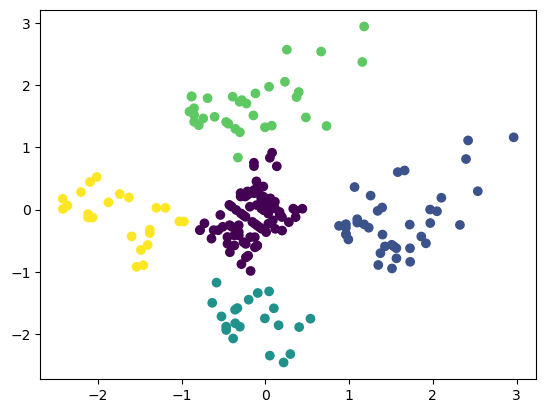

In [27]:
plt.scatter(x_pca[:,0],x_pca[:,1],c=y_gmm,cmap='viridis')

In [ ]:
Association rule learning:
it is used to identify the patterns and relationships inside the data
it is used for showing the frequent items bought together
this is also called as market basket analysis

In [ ]:
Algorithms:
Apriori
eclat
f-p growth

In [ ]:
antecendents
consequents

element is called as antecedents
statement is called as consequent

In [ ]:
metrics of association rule learning:
support
lift 
confidence

In [10]:
import pandas as pd

In [11]:
from mlxtend.preprocessing import TransactionEncoder

In [12]:
from mlxtend.frequent_patterns import apriori,association_rules

In [13]:
dataset=[
    ['milk','bread','butter','eggs'],
    ['milk','bread'],
    ['bread','eggs','butter'],
    ['bread','eggs'],
    ['bread']]

In [14]:
te=TransactionEncoder()
te_array=te.fit_transform(dataset)

In [15]:
te_array

array([[ True,  True,  True,  True],
       [ True, False, False,  True],
       [ True,  True,  True, False],
       [ True, False,  True, False],
       [ True, False, False, False]])

In [16]:
df=pd.DataFrame(te_array,columns=te.columns_)

In [17]:
df

,bread,butter,eggs,milk
0,True,True,True,True
1,True,False,False,True
2,True,True,True,False
3,True,False,True,False
4,True,False,False,False


In [18]:
frequent_patterns=apriori(df,min_support=0.5,use_colnames=True)

In [19]:
frequent_patterns

,support,itemsets
0,1.0,frozenset({bread})
1,0.6,frozenset({eggs})
2,0.6,"frozenset({bread, eggs})"


In [20]:
rules=association_rules(frequent_patterns,metric='confidence')

C:\Users\Kavyashree N\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [21]:
rules[['antecedents','consequents','support','lift','confidence']]

,antecedents,consequents,support,lift,confidence
0,frozenset({eggs}),frozenset({bread}),0.6,1.0,1.0


In [22]:
from mlxtend.frequent_patterns import fpgrowth,association_rules

In [23]:
te=TransactionEncoder()
te_array=te.fit(dataset).transform(dataset)
df=pd.DataFrame(te_array,columns=te.columns_)

In [24]:
frequent_itemsets=fpgrowth(df,min_support=0.4,use_colnames=True)

In [25]:
frequent_itemsets

,support,itemsets
0,1.0,frozenset({bread})
1,0.6,frozenset({eggs})
2,0.4,frozenset({milk})
3,0.4,frozenset({butter})
4,0.6,"frozenset({bread, eggs})"
5,0.4,"frozenset({bread, milk})"
6,0.4,"frozenset({eggs, butter})"
7,0.4,"frozenset({bread, butter})"
8,0.4,"frozenset({bread, eggs, butter})"


In [26]:
def create_tidsets(dataset):
    tidsets = {}
    for tid, transaction in enumerate(dataset):
        for item in transaction:
            if item not in tidsets:
                tidsets[item] = set()
            tidsets[item].add(tid)
    return tidsets

# ECLAT recursive function
def eclat(prefix, items, min_support, freq_items):
    while items:
        item, tidset = items.pop()
        support = len(tidset)
        
        if support >= min_support:
            new_prefix = prefix + [item]
            freq_items.append((new_prefix, support))
            
            # Build new combinations
            new_items = []
            for other_item, other_tidset in items:
                intersection = tidset & other_tidset
                if len(intersection) >= min_support:
                    new_items.append((other_item, intersection))
            
            # Recursive call
            eclat(new_prefix, new_items, min_support, freq_items)

# Run ECLAT
min_support = 2

tidsets = create_tidsets(dataset)
items = list(tidsets.items())

freq_items = []
eclat([], items, min_support, freq_items)

# Print results
print("Frequent Itemsets:")
for itemset, support in freq_items:
    print(f"{itemset} -> Support: {support}")

Frequent Itemsets:
['eggs'] -> Support: 3
['eggs', 'butter'] -> Support: 2
['eggs', 'butter', 'bread'] -> Support: 2
['eggs', 'bread'] -> Support: 3
['butter'] -> Support: 2
['butter', 'bread'] -> Support: 2
['bread'] -> Support: 5
['bread', 'milk'] -> Support: 2
['milk'] -> Support: 2


In [ ]:
project 1:

customer churn prediction system:

data collection
data preparation
data cleaning:
>>null values
>>remove the duplicates
>>fix formats
>>fix the country names

feature engineering:
convert the date
encode the categorical variaables

eda(exploratory data analysis)

who churns more?
income vs churn
spending vs churn

model selection:
logistic regression
knn
naive bayes
svm
decision tree
random forest

evaluation metrics:
accuracy
precision
recall
f1-score

built streamlit application


record the screen with your voice and explanation

In [ ]:
project 2:

Ecommerce customer behaviour analysis and recommendation systems

with the help of unsupervised algorithm like:

clustering
Association rule learning

perform customer segmentation(clustering)
recommendations/suggestions(Association rule learning)


data collection
data preparation
data cleaning:
null values
duplicates
wrong data
wrong format
feature engineering:
label encoding
one hot encoding
model selection:
kmeans
hiearchical clustering
dbscan
gmm

Apriori
eclat
f-p growth

model evaluation

deployement to streamlit

record the screen and audio with explanation

In [ ]:
project 1:
pizza sales analysis by using python+sql+powerbi

project 2:
customer churn prediction
python+eda+ml--->streamlit deployement

project 3:
e-commerce customer behaviour and recomemndation system
python+eda+ml--->streamlit deployement